In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyccl as ccl
import pylab as plt
import matplotlib.cm as cm
from scipy.special import erf
%matplotlib inline

CSV reader of FLAMINGO simulations

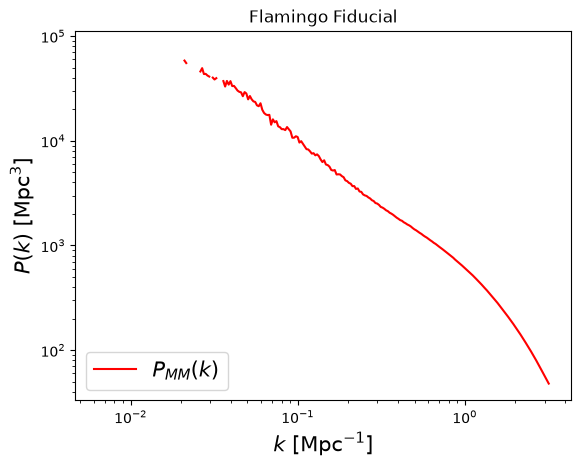

In [ ]:

fname_pk = r"/mnt/extraspace/smaleubre/Flamingo_Analysis/L1000N1800/HYDRO_FIDUCIAL/snap_0077/power_spectrum/nfft_1024/cross_m_density_gas_density_nfft1024.csv"

Pk = pd.read_csv(fname_pk, header=9, sep=' ') 

kmin = Pk['kmin'].to_numpy()  
kmax = Pk['kmax'].to_numpy()
power = Pk['power'].to_numpy()

##### PS <ee> - factor for emissivity-emissivity cross
#power = power * 1*10**(-40)
##### PS <eX> - factor for emissivity-other cross
#power = power * 1*10**(-20)


average = (kmin + kmax) / 2

plt.figure()
plt.plot(average, power, 'r-', label='$P_{MgS}(k)$')
plt.xscale('log')
plt.yscale('log')
plt.title("Flamingo Fiducial")
plt.legend(loc='lower left', fontsize=15)
plt.ylabel(r'$P(k)\,\,[{\rm Mpc}^3]$', fontsize=15)
plt.xlabel(r'$k\,\,[{\rm Mpc}^{-1}]$', fontsize=15);
plt.show()

Halo model

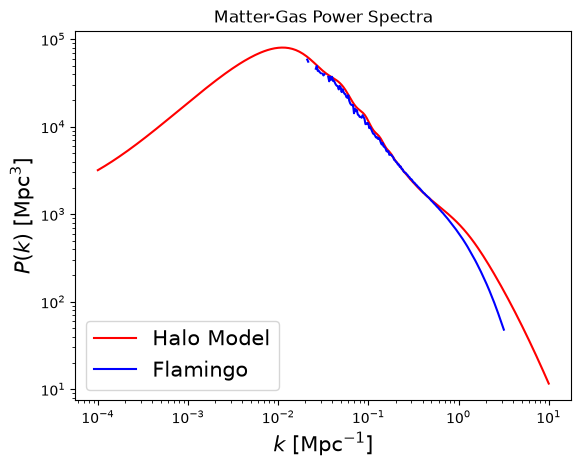

In [3]:


# -----Cosmologies-----
#hydro_fiducial, hydro_weak_agn, hydro_strong_agn, hydro_stronger_agn, hydro_strongest_agn, 
# hydro_strong_supernova, hydro_stronger_agn_strong_supernova, hydro_jets_published
cosmo = ccl.Cosmology(Omega_c=0.2574, Omega_b=0.0486, h=0.681, sigma8=0.815, n_s=0.967)

# Wavenumbers and scale factors
k1 = np.geomspace(1E-4,1E1,256)
a_arr = np.linspace(0.1,1,32)

# We will use a mass definition with Delta = 200 times the matter density
hmd_200m = ccl.halos.MassDef200m

# The Duffy 2008 concentration-mass relation
cM = ccl.halos.ConcentrationDuffy08(mass_def=hmd_200m)

# The Tinker 2008 mass function
nM = ccl.halos.MassFuncTinker08(mass_def=hmd_200m)

# The Tinker 2010 halo bias
bM = ccl.halos.HaloBiasTinker10(mass_def=hmd_200m)

# The NFW profile to characterize the matter density around halos
pM = ccl.halos.HaloProfileNFW(mass_def=hmd_200m, concentration=cM, fourier_analytic=True)

pg = ccl.halos.HaloProfileHOD(mass_def=hmd_200m, concentration=cM)

hmc = ccl.halos.HMCalculator(mass_function=nM, halo_bias=bM, mass_def=hmd_200m)

pk_MM = ccl.halos.halomod_power_spectrum(cosmo, hmc, k1, 1., pM)

pk_gM = ccl.halos.halomod_power_spectrum(cosmo, hmc, k1, 1., pM)

plt.figure()
plt.plot(k1, pk_MM, 'r-', label='Halo Model')
# plt.plot(k1, pk_gM, 'r-', label='$CCL$')
# plt.plot(k_arr, pk_gg, 'y-', label='$P_{gg}(k)$')
plt.plot(average, power, 'b-', label='Flamingo')

plt.title("Matter-Gas Power Spectra")
plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower left', fontsize=15)
plt.ylabel(r'$P(k)\,\,[{\rm Mpc}^3]$', fontsize=15)
plt.xlabel(r'$k\,\,[{\rm Mpc}^{-1}]$', fontsize=15);

Baryonification

In [4]:
import utils as ut

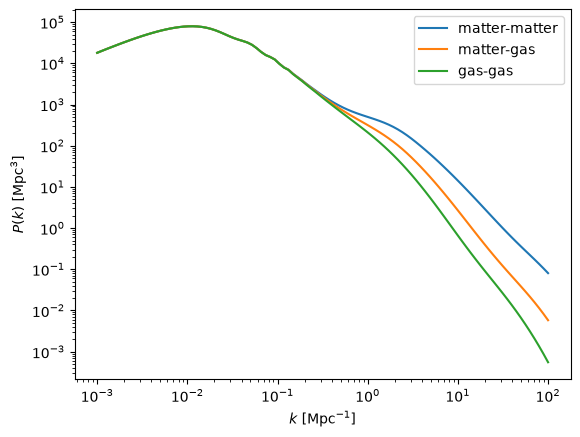

In [5]:

nM = ccl.halos.MassFuncTinker08(mass_def='200c')
bM = ccl.halos.HaloBiasTinker10(mass_def='200c')
cM = ut.ConcentrationDutton14(mass_def='200c')
mv2mt = ut.Mvir2MtotNFWt(concentration_f=cM)
pgas = ut.HaloProfileGasBFCDavid(mass_def='200c', log10Mc=6, mu=0.2, delta=3.0,
                                 Mvir2Mtot=mv2mt)
pmat = ccl.halos.HaloProfileNFW(mass_def='200c', concentration=cM)

# Define new halo model calculator using the total mass as normalisation of the gas profile
hmc = ccl.halos.HMCalculator(mass_function=nM, halo_bias=bM, mass_def='200c',
                             log10M_min=10.0, log10M_max=15.0, nM=64)




# Create the Cosmology object
#D3A cosmology
cosmo_lcdm = ccl.Cosmology(Omega_c=0.2574,   # Cold dark matter density fraction
    Omega_b=0.0486,   # Baryon density fraction
    h=0.681,         # Hubble constant / 100
    A_s=2.099e-9,     # Primordial amplitude
    n_s=0.967        # Spectral index
    )


k_arr = np.geomspace(1E-3, 1E2, 100)
lk_arr = np.log(k_arr)
z_arr = np.linspace(0, 2, 16)
a_arr = 1/(1+z_arr[::-1])
pk_mm = ccl.halos.pk_2pt.halomod_Pk2D(cosmo, hmc, pmat, prof2=pmat, lk_arr=lk_arr, a_arr=a_arr)
pk_mg = ccl.halos.pk_2pt.halomod_Pk2D(cosmo, hmc, pmat, prof2=pgas, lk_arr=lk_arr, a_arr=a_arr)
pk_gg = ccl.halos.pk_2pt.halomod_Pk2D(cosmo, hmc, pgas, prof2=pgas, lk_arr=lk_arr, a_arr=a_arr)

plt.plot(k_arr, pk_mm(k_arr, 1.0), label='matter-matter')
plt.plot(k_arr, pk_mg(k_arr, 1.0), label='matter-gas')
plt.plot(k_arr, pk_gg(k_arr, 1.0), label='gas-gas')
plt.loglog()
plt.xlabel(r'$k\,\,[{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)\,\,[{\rm Mpc}^3]$')
plt.legend()
plt.show()

Plotting

Text(0.5, 1.0, 'HYDRO_FIDUCIAL')

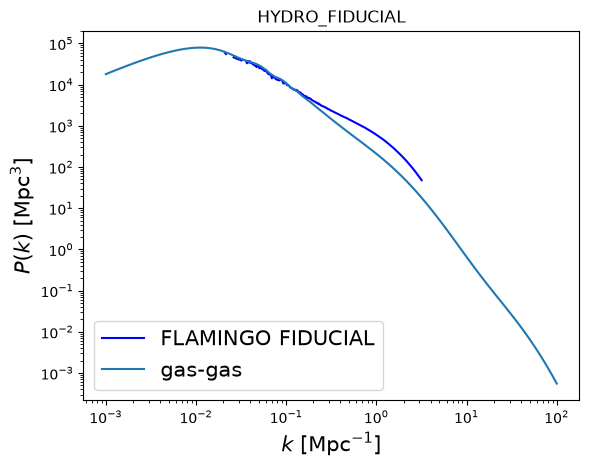

In [6]:
plt.figure()
plt.plot(average, power, 'b-', label='FLAMINGO FIDUCIAL')
plt.xscale('log')
plt.yscale('log')
#plt.plot(k_arr, pk_mm(k_arr, 1.0), label='matter-matter') 
plt.plot(k_arr, pk_gg(k_arr, 1.0), label='gas-gas') 
#plt.plot(k_arr, pk_mg(k_arr, 1.0), label='matter-gas')
plt.legend(loc='lower left', fontsize=15)
plt.ylabel(r'$P(k)\,\,[{\rm Mpc}^3]$', fontsize=15)
plt.xlabel(r'$k\,\,[{\rm Mpc}^{-1}]$', fontsize=15)
#plt.xlim(10**(-3), 0)
plt.title('HYDRO_FIDUCIAL')